<a href="https://colab.research.google.com/github/lhgiangg/NLP/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image shape: (1365, 2048, 3)
Image shape: (1365, 2048)


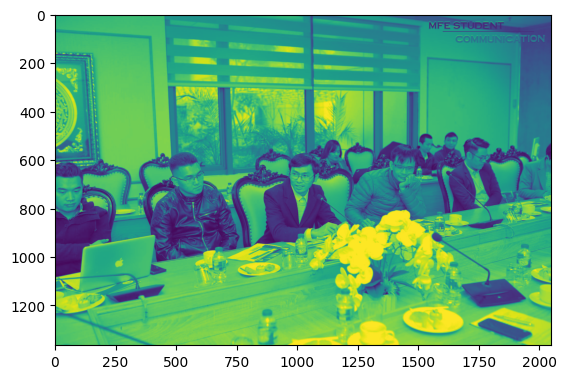

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
from io import BytesIO

img = Image.open('image.png')

f = 'image.png'

X = np.array(Image.open(f))
print('Image shape: %s'%str(X.shape))
# Convert to grey
X = X.dot([0.299, 0.5870, 0.114])
print('Image shape: %s'%str(X.shape))
plt.imshow(X)



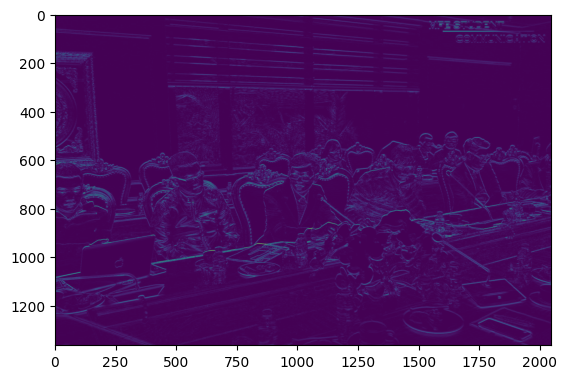

In [ ]:
#Tạo bộ lọc ngang F1
F1 = np.array([[-1, -1, -1],
              [0, 0, 0],
              [1, 1, 1]])
#Tính tích chập 2 chiều.
def conv2d(X, F, s = 1, p = 0):
    """
    X: Ma trận đầu vào
    F: Ma trận bộ lọc
    s: Bước trượt
    p: Độ rộng lề thêm vào
    """
    (w1, h1) = X.shape
    f = F.shape[0]
    w2 = int((w1 + 2*p - f)/s) + 1
    h2 = int((h1 + 2*p - f)/s) + 1
    Y = np.zeros((w2, h2))
    X_pad = np.pad(X, pad_width = p, mode = 'constant', constant_values = 0)
    for i in range(w2):
        for j in range(h2):
            idw = i*s
            idh = j*s
            Y[i, j] = np.abs(np.sum(X_pad[idw:(idw+f), idh:(idh+f)]*F))
    return Y

Y1 = conv2d(X, F1, s = 1, p = 0)
plt.imshow(Y1)

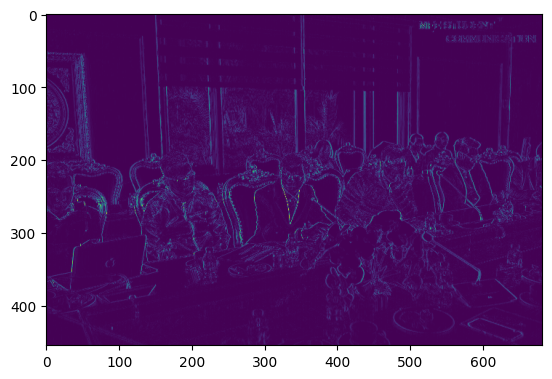

In [ ]:
#Tạo bộ lọc dọc F2
F2 = np.array([[1, 0, -1],
             [1, 0, -1],
             [1, 0, -1]])
Y2 = conv2d(X, F2, s = 3, p = 0)
plt.imshow(Y2)

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging # Import the logging module

# Configure TensorFlow's logging to use Python's logging
# You can adjust the level (e.g., logging.INFO, logging.ERROR) as needed.
tf.get_logger().setLevel(logging.INFO)

def cnn_model_fn(features, labels, mode):
    """Model function for CNN"""
    #Input layer
    input_layer = tf.reshape(features['x'], shape = [-1, 28, 28, 1])

    #Convolution layer 1
    conv1 = tf.layers.conv2d(
        inputs = input_layer,
        filters = 32,
        kernel_size = [5, 5],
        padding = 'same',
        activation = tf.nn.relu)
    #Apply formula:N1 = (N+2P-f)/S + 1
    #in which: N is input image size, P is padding size, f is filter size and S is step
    #Output tensor shape: N1 = (28-5)/1+1 = 24 => shape = [-1, 24, 24, 1]
    #But we at parameter we set padding = 'same' in order to keep output shape unchange to input shape
    #Thus output shape is [-1, 28, 28, 1]

    #Max pooling layer 1
    pool1 = tf.layers.max_pooling2d(
        inputs = conv1,
        pool_size = [2, 2],
        strides = 2)
    #Output tensor shape: N2 = (28-2)/2+1 = 14 => shape = [-1, 14, 14, 1]

    #Convolution layer 2
    conv2 = tf.layers.conv2d(
        inputs = pool1,
        filters = 64,
        kernel_size = [5, 5],
        padding = 'same',
        activation = tf.nn.relu)
    #Output tensor shape: N3 = (14-5)/1+1 = 10 => shape = [-1, 10, 10, 1]
    #But padding = 'same' so output shape is [-1, 14, 14, 1]

    #Max pooling layer 2
    pool2 = tf.layers.max_pooling2d(
        inputs = conv2,
        pool_size = [2, 2],
        strides = 2)
    #Output tensor shape: N4 = (14-2)/2+1 = 7 => shape = [-1, 7, 7, 1]

    #Dense layer
    flat = tf.reshape(pool2, [-1, 7*7*64])
    dense = tf.layers.dense(
        inputs = flat,
        units = 1024,
        activation = tf.nn.relu)

    dropout = tf.layers.dropout(
        inputs = dense,
        rate = 0.4,
        training = mode == tf.estimator.ModeKeys.TRAIN)

    #Logits layer
    logits = tf.layers.dense(inputs = dropout, units = 10)

    predictions = {
        'classes': tf.argmax(input = logits, axis = 1, name = 'class_tensor'),
        'probabilities': tf.nn.softmax(logits, name = 'softmax_tensor')}

    if mode == tf.estimator.ModeKeys.PREDICT:
        return tf.estimator.EstimatorSpec(mode = mode, predictions = predictions)

    loss = tf.losses.sparse_softmax_cross_entropy(labels = labels, logits = logits)

    if mode == tf.estimator.ModeKeys.TRAIN:
        optimizer = tf.train.AdamOptimizer(learning_rate = 0.001)
        train_op = optimizer.minimize(
            loss = loss,
            global_step = tf.train.get_global_step())
        return tf.estimator.EstimatorSpec(mode = mode, loss = loss, train_op = train_op)

    if mode == tf.estimator.ModeKeys.EVAL:
        eval_metric_ops = {
            'accuracy': tf.metrics.accuracy(
            labels = labels, predictions = predictions['classes'])}
        return tf.estimator.EstimatorSpec(
            mode = mode, loss = loss, eval_metric_ops = eval_metric_ops)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Tải dữ liệu MNIST
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# Chuẩn hóa dữ liệu (0-1)
train_data = train_data.astype('float32') / 255.0
test_data = test_data.astype('float32') / 255.0

print('Train images shape      :', train_data.shape)
print('Train labels shape      :', train_labels.shape)
print('Test  images shape      :', test_data.shape)
print('Test  labels shape      :', test_labels.shape)



Train images shape      : (60000, 28, 28)
Train labels shape      : (60000,)
Test  images shape      : (10000, 28, 28)
Test  labels shape      : (10000,)


In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
#https://www.tensorflow.org/tutorials/images/cnn?hl=vi
#https://drive.google.com/drive/folders/148FSsgYndc58P4NV4SvfecPcih5xav72?usp=sharing

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


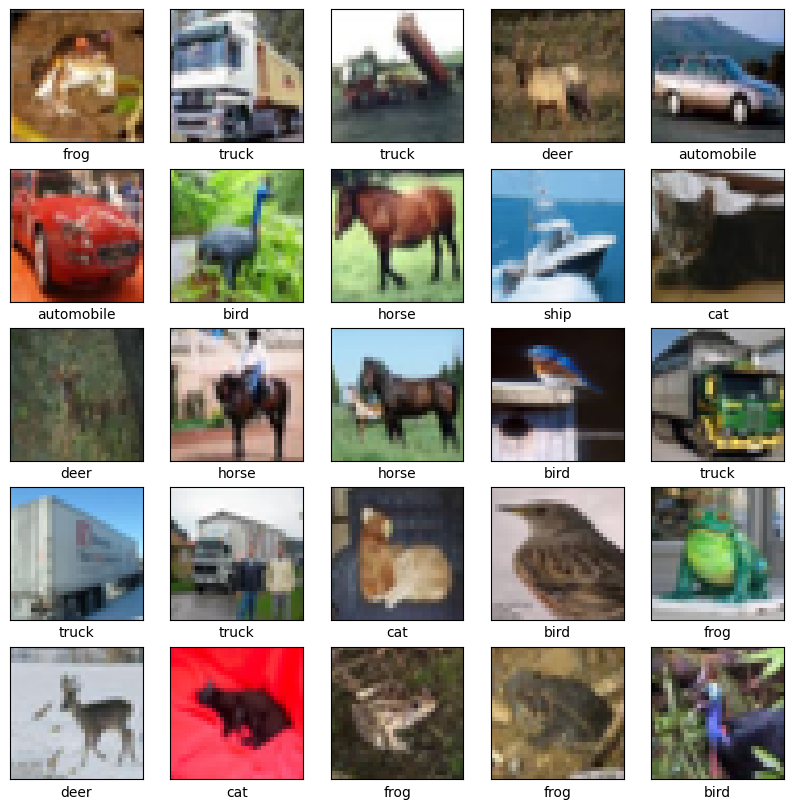

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
  layers.Conv2D(13, 5, activation='relu',strides=2, padding='same', input_shape=(31, 41, 3)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(43, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(11, activation='softmax')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 16, 21, 13)     │           988 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 10, 13)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 8, 43)       │         5,074 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 4, 43)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 516)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        66,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,657 (287.72 KB)

 Trainable params: 73,657 (287.72 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,924 (484.08 KB)

 Trainable params: 123,924 (484.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Redefine the model specifically for CIFAR-10
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary() # Print summary to confirm the input shape

# Assuming train_images, train_labels, test_images, test_labels are already loaded and normalized for CIFAR-10

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# The evaluation section below needs to use the test data from CIFAR-10 (test_images, test_labels),
# not x_test, y_test which are likely from the MNIST dataset.
# Evaluate the model using the correct test data (CIFAR-10 test_images and test_labels)
# test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2) # Incorrect test data source
#test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2) # Corrected test data source

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 41ms/step - accuracy: 0.3615 - loss: 1.7331 - val_accuracy: 0.5540 - val_loss: 1.2648
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.5868 - loss: 1.1632 - val_accuracy: 0.6198 - val_loss: 1.0774
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.6507 - loss: 0.9878 - val_accuracy: 0.6729 - val_loss: 0.9347
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 43ms/step - accuracy: 0.6931 - loss: 0.8737 - val_accuracy: 0.6772 - val_loss: 0.9327
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.7203 - loss: 0.8013 - val_accuracy: 0.6883 - val_loss: 0.8968
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.7372 - loss: 0.7380 - val_accuracy: 0.7095 - val_loss: 0.8404
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7617 - loss: 0.6843 - val_accuracy: 0.7079 - val_loss: 0.8686
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7794 -

313/313 - 4s - 14ms/step - accuracy: 0.7108 - loss: 0.8791


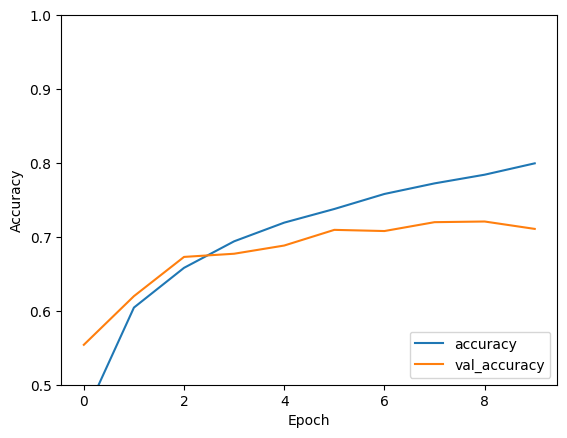

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

0.7107999920845032
